# Sesión 11: autovalores, autovectores

**Curso:** Estadística Multivariable Aplicada para Ciencia de Datos  
**Propósito:** comprender, con rigor y de forma aplicada, por qué los autovalores y autovectores son la base geométrica y estadística de la síntesis multivariada y del paso posterior hacia PCA.

Este notebook desarrolla los temas de las sesiones 11 y 12 del microcurrículo: **autovalores y autovectores (interpretación), descomposición espectral de $\Sigma$, varianza explicada y direcciones principales**. En el programa, estos temas aparecen inmediatamente antes de la derivación operativa de PCA y del taller aplicado con datos reales. La conexión es directa: PCA reexpresa los datos en las direcciones donde la variación es mayor, y esas direcciones vienen dadas por los autovectores de la matriz de covarianza; la magnitud de esa variación viene dada por los autovalores.

## Resultados esperados

Al finalizar este notebook, el estudiante debería poder:

1. Definir con precisión qué son autovalores y autovectores.
2. Explicar por qué la matriz de covarianza $\Sigma$ es el objeto central en este bloque.
3. Interpretar geométricamente la acción de $\Sigma$ sobre el espacio.
4. Hallar autovalores y autovectores en ejemplos simples.


## Requisitos mínimos previos

Se asume familiaridad con:

- vectores y matrices;
- producto matriz-vector;
- media y covarianza muestral;
- interpretación básica de dispersión en dos variables.

## Idea guía del bloque

En estadística multivariable no basta con analizar cada variable por separado. Lo importante es entender la **estructura conjunta**. La matriz de covarianza $\Sigma$ resume esa estructura: cuánto varía cada variable y cómo varían conjuntamente.

Pero $\Sigma$ no solo resume magnitudes. También contiene **direcciones preferentes de variación**. Descubrir esas direcciones es exactamente el papel de los autovectores, y medir cuánta variabilidad hay en cada una es el papel de los autovalores.

In [1]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eig, eigh
from matplotlib.patches import Ellipse

# Para visualizaciones interactivas
import plotly.graph_objects as go
import plotly.express as px

np.set_printoptions(precision=4, suppress=True)

## 1. ¿Por qué aparece este tema en estadística multivariable?

En este curso venimos trabajando con estructura multivariada, covarianza, normal bivariada e inferencia sobre vectores de medias. El paso siguiente es estudiar cómo la **matriz de covarianza** puede ser descompuesta en direcciones fundamentales de variación. Eso permite pasar de una descripción conjunta a una representación más estructural y sintética.

En términos de ciencia de datos, este tema es importante porque:

- ayuda a detectar redundancia entre variables;
- permite identificar ejes de variación dominante;
- prepara el camino para reducción de dimensión;
- mejora la interpretación geométrica de un conjunto de datos multivariado.

En otras palabras, aquí empezamos a pasar de la pregunta

$$
\text{"¿cómo varían estas variables?"}
$$

a la pregunta

$$
\text{"¿en qué direcciones del espacio varían realmente los datos?"}
$$

## 2. La matriz de covarianza como objeto central

Sea $X = (X_1,\dots,X_p)^T$ un vector aleatorio de dimensión $p$, con media $\mu = E(X)$. Su matriz de covarianza es

$$
\Sigma = E\left[(X-\mu)(X-\mu)^T\right].
$$

### ¿Qué contiene $\Sigma$?

- En la diagonal: las varianzas de cada componente.
- Fuera de la diagonal: las covarianzas entre pares de variables.

### ¿Por qué $\Sigma$ es especial?

En este bloque, $\Sigma$ tiene tres propiedades clave:

1. es una matriz cuadrada de tamaño $p \times p$;
2. es simétrica, es decir, $\Sigma = \Sigma^T$;
3. es semidefinida positiva, es decir,
$$
a^T \Sigma a \ge 0
$$
para todo vector $a$.

Estas propiedades garantizan que:

- sus autovalores son reales;
- sus autovalores no son negativos.

Eso es exactamente lo que hace posible la interpretación estadística.

In [2]:
# Ejemplo simple de matriz de covarianza
Sigma = np.array([[4, 2],
                  [2, 3]], dtype=float)

Sigma

array([[4., 2.],
       [2., 3.]])

### Lectura del ejemplo

Para

$$
\Sigma =
\begin{pmatrix}
4 & 2 \\
2 & 3
\end{pmatrix},
$$

tenemos:

- $\mathrm{Var}(X_1)=4$;
- $\mathrm{Var}(X_2)=3$;
- $\mathrm{Cov}(X_1,X_2)=2$.

La covarianza positiva sugiere que ambas variables tienden a moverse en la misma dirección. Pero todavía no sabemos cuáles son las **direcciones principales de dispersión** de la nube de datos. Para eso entran los autovalores y autovectores.

## 3. Definición clara de autovalor y autovector

Sea $A$ una matriz cuadrada de tamaño $p \times p$. Diremos que un escalar $\lambda$ es un **autovalor** de $A$ si existe un vector no nulo $v$ tal que

$$
A v = \lambda v.
$$

En ese caso, $v$ es un **autovector** asociado a $\lambda$.

### Interpretación algebraica

La ecuación

$$
A v = \lambda v
$$

significa que al aplicar la transformación lineal $A$ al vector $v$:

- la dirección de $v$ no cambia;
- solo cambia su escala por el factor $\lambda$.

### Interpretación geométrica

Si pensamos en una matriz como una transformación del espacio, la mayoría de vectores cambian tanto de longitud como de dirección. Los autovectores son especiales: son direcciones que la transformación respeta. Los autovalores dicen cuánto se dilatan o contraen esas direcciones.

### ¿Qué significa esto en una matriz de covarianza?

Si $A=\Sigma$, entonces:

- los autovectores son direcciones geométricamente relevantes de la dispersión;
- los autovalores miden la varianza en esas direcciones.

## 4. Cómo se calculan: idea formal

Para hallar autovalores, partimos de

$$
A v = \lambda v.
$$

Reordenando,

$$
(A-\lambda I)v = 0.
$$

Para que exista una solución no trivial $v \ne 0$, la matriz $A-\lambda I$ debe ser singular. Entonces,

$$
\det(A-\lambda I)=0.
$$

A esta ecuación se le llama **ecuación característica**. Sus raíces son los autovalores. Luego, para cada autovalor, se resuelve

$$
(A-\lambda I)v=0
$$

y así se obtiene el autovector asociado.

## 5. Ejemplo completamente desarrollado en dimensión 2

Tomemos de nuevo

$$
\Sigma =
\begin{pmatrix}
4 & 2 \\
2 & 3
\end{pmatrix}.
$$

Buscamos $\lambda$ tales que

$$
\det(\Sigma-\lambda I)=0.
$$

Entonces,

$$
\det
\begin{pmatrix}
4-\lambda & 2 \\
2 & 3-\lambda
\end{pmatrix}
= (4-\lambda)(3-\lambda)-4 = 0.
$$

Desarrollando,

$$
\lambda^2 - 7\lambda + 8 = 0.
$$

Por fórmula cuadrática,

$$
\lambda_{1,2} = \frac{7 \pm \sqrt{17}}{2}.
$$

Por tanto,

$$
\lambda_1 \approx 5.5616, \qquad \lambda_2 \approx 1.4384.
$$

Ahora hallamos los autovectores resolviendo, para cada autovalor,

$$
(\Sigma-\lambda I)v=0.
$$

### Autovector asociado a $\lambda_1$

Sustituimos $\lambda_1 \approx 5.5616$ en

$$
\Sigma=
\begin{pmatrix}
4 & 2\\
2 & 3
\end{pmatrix},
$$

de modo que

$$
\Sigma-\lambda_1 I=
\begin{pmatrix}
4-5.5616 & 2\\
2 & 3-5.5616
\end{pmatrix}
=
\begin{pmatrix}
-1.5616 & 2\\
2 & -2.5616
\end{pmatrix}.
$$

Buscamos $v=\begin{pmatrix}x\\y\end{pmatrix}$ tal que

$$
\begin{pmatrix}
-1.5616 & 2\\
2 & -2.5616
\end{pmatrix}
\begin{pmatrix}
x\\
y
\end{pmatrix}
=
\begin{pmatrix}
0\\
0
\end{pmatrix}.
$$

Esto produce el sistema

$$
-1.5616x+2y=0,
$$

$$
2x-2.5616y=0.
$$

Ambas ecuaciones son equivalentes, así que basta usar una de ellas. De la primera:

$$
2y=1.5616x
\quad\Rightarrow\quad
y=0.7808x.
$$

Si tomamos, por ejemplo, $x=1$, obtenemos un autovector proporcional a

$$
v_1=
\begin{pmatrix}
1\\
0.7808
\end{pmatrix}.
$$

Ahora lo normalizamos. Su norma es

$$
\|v_1\|=\sqrt{1^2+0.7808^2}\approx 1.2688.
$$

Por tanto, el autovector normalizado es aproximadamente

$$
u_1=
\frac{1}{1.2688}
\begin{pmatrix}
1\\
0.7808
\end{pmatrix}
\approx
\begin{pmatrix}
0.7881\\
0.6156
\end{pmatrix}.
$$

### Autovector asociado a $\lambda_2$

Sustituimos ahora $\lambda_2 \approx 1.4384$:

$$
\Sigma-\lambda_2 I=
\begin{pmatrix}
4-1.4384 & 2\\
2 & 3-1.4384
\end{pmatrix}
=
\begin{pmatrix}
2.5616 & 2\\
2 & 1.5616
\end{pmatrix}.
$$

Buscamos $v=\begin{pmatrix}x\\y\end{pmatrix}$ tal que

$$
\begin{pmatrix}
2.5616 & 2\\
2 & 1.5616
\end{pmatrix}
\begin{pmatrix}
x\\
y
\end{pmatrix}
=
\begin{pmatrix}
0\\
0
\end{pmatrix}.
$$

Esto da el sistema

$$
2.5616x+2y=0,
$$

$$
2x+1.5616y=0.
$$

De la primera ecuación se obtiene

$$
2y=-2.5616x
\quad\Rightarrow\quad
y=-1.2808x.
$$

Tomando $x=1$, obtenemos un autovector proporcional a

$$
v_2=
\begin{pmatrix}
1\\
-1.2808
\end{pmatrix}.
$$

Su norma es

$$
\|v_2\|=\sqrt{1^2+(-1.2808)^2}\approx 1.6249.
$$

Entonces el autovector normalizado es aproximadamente

$$
u_2=
\frac{1}{1.6249}
\begin{pmatrix}
1\\
-1.2808
\end{pmatrix}
\approx
\begin{pmatrix}
0.6156\\
-0.7881
\end{pmatrix}.
$$

En consecuencia, los autovectores normalizados son aproximadamente

$$
u_1 \approx
\begin{pmatrix}
0.7881\\
0.6156
\end{pmatrix},
\qquad
u_2 \approx
\begin{pmatrix}
0.6156\\
-0.7881
\end{pmatrix}.
$$

Estas dos direcciones son ortogonales. La dirección $u_1$, asociada al autovalor mayor, corresponde a la dirección principal de variación; la dirección $u_2$ corresponde a la variación secundaria.

In [3]:
Sigma = np.array([[4, 2],
                  [2, 3]], dtype=float)

eigvals, eigvecs = eigh(Sigma)  # eigh aprovecha que Sigma es simétrica
idx = np.argsort(eigvals)[::-1]  # ordenar de mayor a menor
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Autovalores:")
print(eigvals)
print("\nAutovectores (columnas):")
print(eigvecs)

Autovalores:
[5.5616 1.4384]

Autovectores (columnas):
[[-0.7882  0.6154]
 [-0.6154 -0.7882]]


### Interpretación del resultado numérico

Si el autovector principal es, por ejemplo,

$$
v_1 =
\begin{pmatrix}
0.7882 \\
0.6154
\end{pmatrix},
$$

eso significa que la dirección dominante de la nube de datos es una combinación lineal positiva de ambas variables.

Y si el segundo autovector es

$$
v_2 =
\begin{pmatrix}
-0.6154 \\
0.7882
\end{pmatrix},
$$

entonces representa una dirección ortogonal a la primera, es decir, una dirección transversal de variación.

Los autovalores asociados indican cuánta varianza hay en esas direcciones:

- dirección principal: varianza aproximada $5.56$;
- dirección secundaria: varianza aproximada $1.44$.

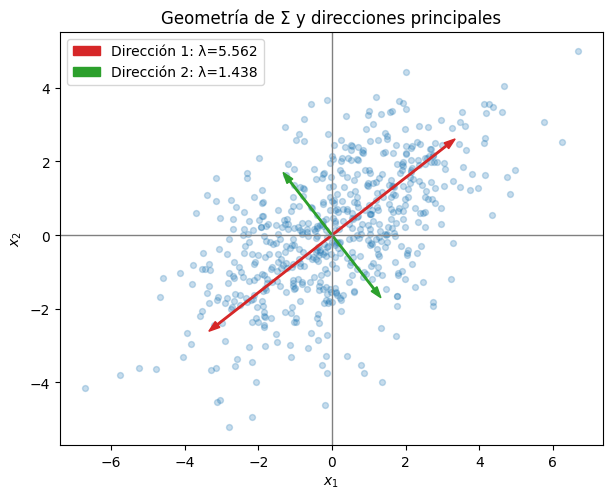

In [4]:
# Visualización geométrica de la matriz de covarianza y sus autovectores

def plot_covariance_geometry(Sigma, scale=1.8, title="Geometría de Σ y direcciones principales"):
    eigvals, eigvecs = eigh(Sigma)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Datos simulados con esa covarianza
    mean = np.array([0, 0])
    X = np.random.multivariate_normal(mean, Sigma, size=600)

    fig, ax = plt.subplots(figsize=(7,7))
    ax.scatter(X[:,0], X[:,1], alpha=0.25, s=18)

    # Dibujar autovectores escalados por raíz del autovalor
    colors = ["tab:red", "tab:green"]
    for i in range(2):
        v = eigvecs[:, i]
        l = eigvals[i]
        ax.arrow(0, 0,
                 scale*np.sqrt(l)*v[0],
                 scale*np.sqrt(l)*v[1],
                 width=0.04,
                 head_width=0.20,
                 length_includes_head=True,
                 color=colors[i],
                 label=f"Dirección {i+1}: λ={l:.3f}")
        ax.arrow(0, 0,
                 -scale*np.sqrt(l)*v[0],
                 -scale*np.sqrt(l)*v[1],
                 width=0.04,
                 head_width=0.20,
                 length_includes_head=True,
                 color=colors[i])

    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend()
    ax.set_aspect("equal")
    plt.show()

plot_covariance_geometry(Sigma)

### Lectura pedagógica de la figura

La nube de puntos se alarga más en la dirección del primer autovector. Eso no es casualidad:

- el **autovector principal** marca el eje de máxima dispersión;
- su **autovalor** cuantifica esa dispersión;
- el segundo autovector, ortogonal al primero, captura la variación restante.

Esa es la intuición esencial de este bloque y también la intuición inicial de PCA.

## Ejercicios propuestos

### Ejercicio 1

Considere la matriz

$$
A=
\begin{pmatrix}
5 & 0 \\
0 & 2
\end{pmatrix}.
$$

1. Halle los autovalores.
2. Halle los autovectores.
3. Interprete geométricamente el resultado.

---

### Ejercicio 2

Considere la matriz

$$
B=
\begin{pmatrix}
3 & 1 \\
1 & 3
\end{pmatrix}.
$$

1. Halle los autovalores.
2. Halle los autovectores.
3. Indique cuál es la dirección principal de variación si esta matriz se interpreta como matriz de covarianza.

---

### Ejercicio 3

Considere la matriz

$$
C=
\begin{pmatrix}
4 & 0 \\
0 & 4
\end{pmatrix}.
$$

1. Halle los autovalores.
2. Describa el conjunto de autovectores.
3. Explique por qué en este caso no hay una única dirección principal.

---

### Ejercicio 4

Considere la matriz

$$
\Sigma=
\begin{pmatrix}
4 & 2 \\
2 & 3
\end{pmatrix}.
$$

1. Calcule los autovalores y autovectores usando código.
2. Verifique numéricamente que los autovectores son ortogonales.
3. Grafique la transformación de una nube de puntos elíptica y superponga las direcciones propias.

---

### Ejercicio 5

Genere una nube de puntos bivariada simulada con correlación positiva y use código para:

1. calcular la matriz de covarianza muestral;
2. obtener sus autovalores y autovectores;
3. visualizar la nube de puntos junto con las direcciones principales;
4. interpretar cuál dirección concentra mayor variabilidad.

---
